✅ 3D Asset saved: ../../../assets/54_pca_3d.png


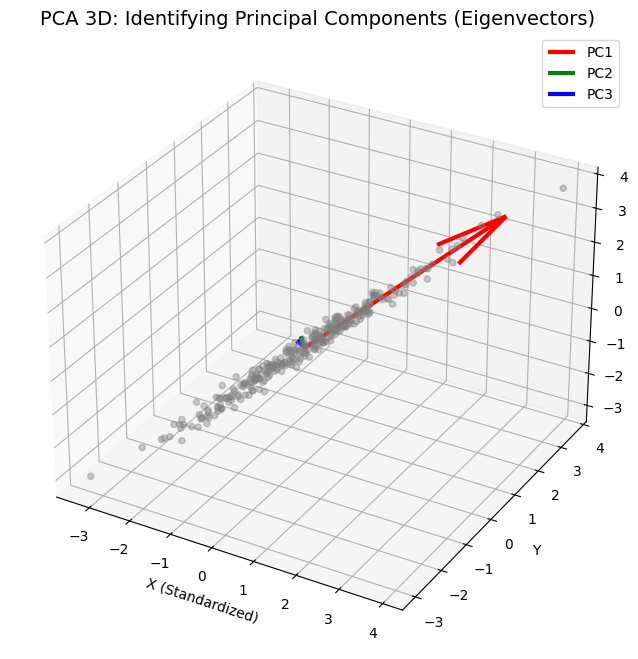

✅ 2D Asset saved: ../../../assets/54_pca_2d.png


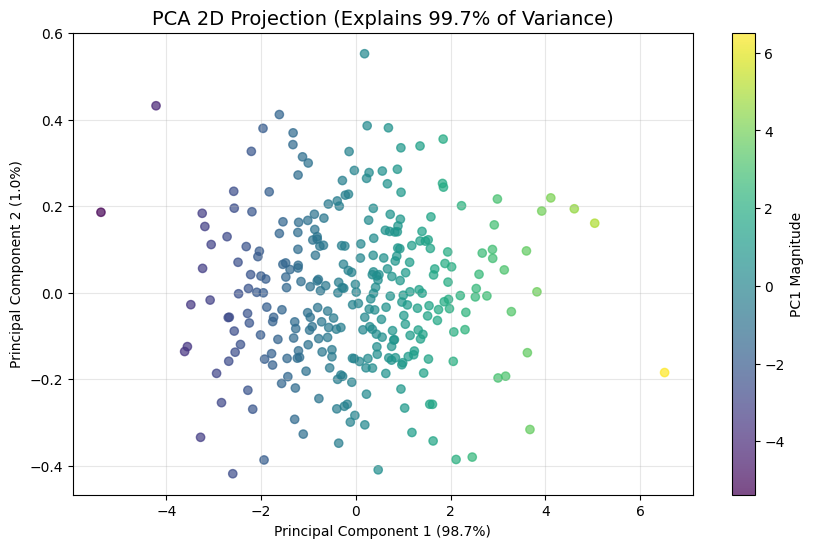

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

def run_pca_master():
    # --- PROFESSIONAL PATH SETUP (Relative Path) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Create a Synthetic 3D Dataset with a clear 'main direction'
    np.random.seed(42)
    n_points = 300
    x = np.random.normal(0, 1, n_points)
    y = 0.8 * x + np.random.normal(0, 0.2, n_points)
    z = 0.5 * x + 0.5 * y + np.random.normal(0, 0.1, n_points)
    data = np.vstack([x, y, z]).T

    # 2. Standardize and Run PCA
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    pca = PCA(n_components=3)
    pca.fit(data_scaled)
    data_pca = pca.transform(data_scaled)

    # --- 📸 ASSET 1: 3D DATA CLOUD & EIGENVECTORS (54_pca_3d.png) ---
    fig1 = plt.figure(figsize=(10, 8))
    ax3d = fig1.add_subplot(111, projection='3d')
    
    ax3d.scatter(data_scaled[:,0], data_scaled[:,1], data_scaled[:,2], alpha=0.4, color='gray')
    
    # Plot Eigenvectors (Principal Components)
    colors = ['r', 'g', 'b']
    for i, (length, vector) in enumerate(zip(pca.explained_variance_, pca.components_)):
        v = vector * 3 * np.sqrt(length) # Scale for visibility
        ax3d.quiver(0, 0, 0, v[0], v[1], v[2], color=colors[i], lw=3, label=f'PC{i+1}')

    ax3d.set_title("PCA 3D: Identifying Principal Components (Eigenvectors)", fontsize=14)
    ax3d.set_xlabel("X (Standardized)"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")
    ax3d.legend()
    
    plt.savefig(os.path.join(asset_path, '54_pca_3d.png'), dpi=300)
    print(f"✅ 3D Asset saved: {asset_path}/54_pca_3d.png")
    plt.show()

    # --- 📸 ASSET 2: 2D PROJECTION (54_pca_2d.png) ---
    fig2 = plt.figure(figsize=(10, 6))
    plt.scatter(data_pca[:, 0], data_pca[:, 1], c=data_pca[:, 0], cmap='viridis', alpha=0.7)
    
    var_exp = pca.explained_variance_ratio_
    plt.title(f"PCA 2D Projection (Explains {sum(var_exp[:2])*100:.1f}% of Variance)", fontsize=14)
    plt.xlabel(f"Principal Component 1 ({var_exp[0]*100:.1f}%)")
    plt.ylabel(f"Principal Component 2 ({var_exp[1]*100:.1f}%)")
    plt.grid(alpha=0.3)
    plt.colorbar(label='PC1 Magnitude')
    
    plt.savefig(os.path.join(asset_path, '54_pca_2d.png'), dpi=300)
    print(f"✅ 2D Asset saved: {asset_path}/54_pca_2d.png")
    plt.show()

if __name__ == "__main__":
    run_pca_master()